In [1]:
!nvidia-smi


Wed Feb 18 08:17:55 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   60C    P0             28W /   80W |      11MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import numpy as np
import tensorflow as tf
import keras
import keras_cv

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)


2026-02-18 08:17:55.779043: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-18 08:17:55.788762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771377475.799878    7804 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771377475.803501    7804 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771377475.812200    7804 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TensorFlow version: 2.19.1


In [3]:
DATA_PATH = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/swin_ids/Preprocessing/hasil_preprocessing/prep256/swin_res256_dataset.npz"

data = np.load(DATA_PATH)

X_train = data["X_train"]
y_train = data["y_train"]
X_test  = data["X_test"]
y_test  = data["y_test"]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (9403, 128, 128, 3)
Test shape : (6183, 128, 128, 3)


In [4]:
print("Train label distribution:", np.unique(y_train, return_counts=True))
print("Test label distribution :", np.unique(y_test, return_counts=True))

print("Min value:", X_train.min())
print("Max value:", X_train.max())


Train label distribution: (array([0, 1]), array([3814, 5589]))
Test label distribution : (array([0, 1]), array([3199, 2984]))
Min value: -0.5254788
Max value: 2.4145703


In [5]:
from sklearn.model_selection import train_test_split
import numpy as np

# =========================
# 1. Gabungkan seluruh data
# =========================
X_all = np.concatenate([X_train, X_test], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)

print("Total dataset shape:", X_all.shape)
print("Total label distribution:", np.unique(y_all, return_counts=True))


# =========================
# 2. Split ulang 80:20
# =========================
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    stratify=y_all,
    random_state=42
)

print("\nAfter 8:2 split:")
print("Train shape:", X_train_new.shape)
print("Test shape :", X_test_new.shape)

print("Train label distribution:", np.unique(y_train_new, return_counts=True))
print("Test label distribution :", np.unique(y_test_new, return_counts=True))


Total dataset shape: (15586, 128, 128, 3)
Total label distribution: (array([0, 1]), array([7013, 8573]))

After 8:2 split:
Train shape: (12468, 128, 128, 3)
Test shape : (3118, 128, 128, 3)
Train label distribution: (array([0, 1]), array([5610, 6858]))
Test label distribution : (array([0, 1]), array([1403, 1715]))


In [6]:
import torch
import torch.nn as nn
import timm

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch version: 2.5.1+cu121
CUDA available: True


In [7]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [8]:
model = timm.create_model(
    'swin_tiny_patch4_window7_224',
    pretrained=False,
    num_classes=2,
    img_size=128,   # sesuaikan dengan dataset
    window_size=7
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
EPOCHS = 5
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)


In [9]:
print(model)


SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=96, out_features=288, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=96, out_features=96, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=96, out_features=384, bias=True)
            (act): GELU(approximate='none')
            (drop1): 

In [10]:
import numpy as np

# ubah dari NHWC → NCHW
X_train_pt = torch.tensor(X_train_new).permute(0,3,1,2).float()
X_test_pt  = torch.tensor(X_test_new).permute(0,3,1,2).float()

y_train_pt = torch.tensor(y_train_new).long()
y_test_pt  = torch.tensor(y_test_new).long()
print(X_train_pt.shape)
print(X_test_pt.shape)

torch.Size([12468, 3, 128, 128])
torch.Size([3118, 3, 128, 128])


In [11]:
from torch.utils.data import Dataset, DataLoader

class IDS_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [12]:
train_dataset = IDS_Dataset(X_train_pt, y_train_pt)
test_dataset  = IDS_Dataset(X_test_pt, y_test_pt)


In [13]:


train_loader = DataLoader(
    train_dataset,
    batch_size=10,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=10,
    num_workers=4,
    pin_memory=True
)


In [ ]:
device = torch.device("cuda")
model = model.to(device)

print(next(m++odel.parameters()).device)


cuda:0


In [15]:
from tqdm import tqdm

EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    loop = tqdm(train_loader)

    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_description(f"Epoch {epoch+1}/{EPOCHS}")
        loop.set_postfix(loss=loss.item())

    scheduler.step()

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader):.4f}")


Epoch 1/3: 100%|██████████| 1247/1247 [01:18<00:00, 15.87it/s, loss=0.409]  


Epoch 1 Loss: 0.2488


Epoch 2/3: 100%|██████████| 1247/1247 [01:28<00:00, 14.15it/s, loss=0.488]  


Epoch 2 Loss: 0.1366


Epoch 3/3: 100%|██████████| 1247/1247 [01:47<00:00, 11.56it/s, loss=0.0334] 

Epoch 3 Loss: 0.1012


In [16]:
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        attack_probs = probs[:, 1]

        all_probs.extend(attack_probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [17]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
TN, FP, FN, TP = cm.ravel()

accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP + 1e-8)
recall = TP / (TP + FN + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)
FPR = FP / (FP + TN + 1e-8)
FNR = FN / (FN + TP + 1e-8)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("FPR:", FPR)
print("FNR:", FNR)


Accuracy: 0.9730596536241181
Precision: 0.9722061378056039
Recall: 0.9790087463499767
F1: 0.9755955789572045
FPR: 0.0342124019954796
FNR: 0.02099125364419247


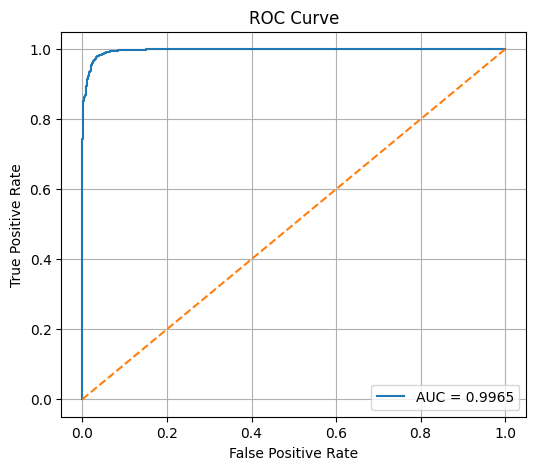

In [18]:
from sklearn.metrics import roc_curve, auc

fpr_curve, tpr_curve, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr_curve, tpr_curve)

plt.figure(figsize=(6,5))
plt.plot(fpr_curve, tpr_curve, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


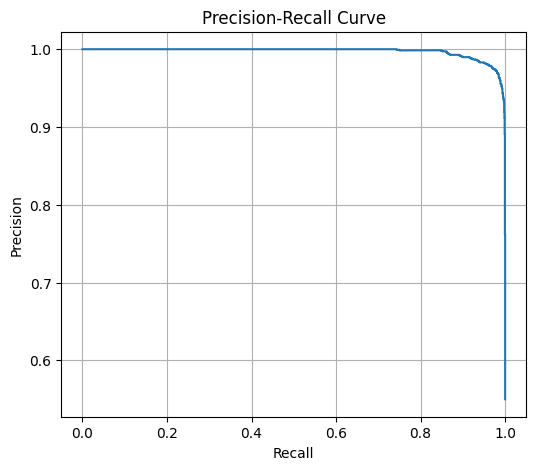

In [19]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(all_labels, all_probs)

plt.figure(figsize=(6,5))
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()


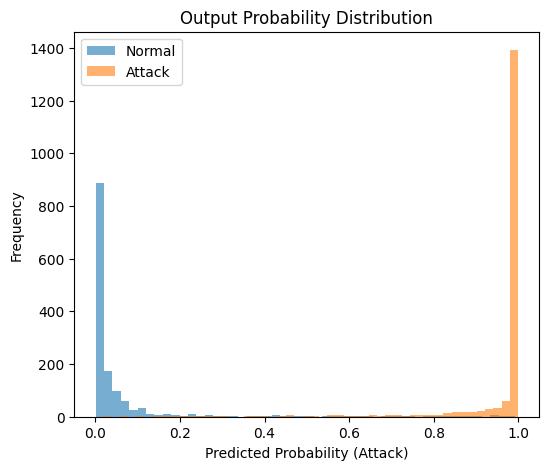

In [20]:
all_probs = np.array(all_probs)

normal_probs = all_probs[np.array(all_labels)==0]
attack_probs = all_probs[np.array(all_labels)==1]

plt.figure(figsize=(6,5))
plt.hist(normal_probs, bins=50, alpha=0.6, label="Normal")
plt.hist(attack_probs, bins=50, alpha=0.6, label="Attack")
plt.legend()
plt.title("Output Probability Distribution")
plt.xlabel("Predicted Probability (Attack)")
plt.ylabel("Frequency")
plt.show()


In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0.0, 1.0, 1001)

best_threshold = 0
min_fp = float('inf')
best_metrics = None

for t in thresholds:
    preds = (np.array(all_probs) >= t).astype(int)
    cm = confusion_matrix(all_labels, preds)

    if cm.shape != (2,2):
        continue

    TN, FP, FN, TP = cm.ravel()

    if FP < min_fp:
        min_fp = FP
        best_threshold = t

        accuracy = (TP + TN) / (TP + TN + FP + FN)
        precision = TP / (TP + FP + 1e-8)
        recall = TP / (TP + FN + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)
        fpr = FP / (FP + TN + 1e-8)
        fnr = FN / (FN + TP + 1e-8)

        best_metrics = {
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "FPR": fpr,
            "FNR": fnr,
            "FP": FP,
            "FN": FN
        }

print("Best Threshold (Min FP):", best_threshold)
print("Metrics at that threshold:")
for k, v in best_metrics.items():
    print(k, ":", v)


Best Threshold (Min FP): 0.994
Metrics at that threshold:
Accuracy : 0.846696600384862
Precision : 0.999999999991916
Recall : 0.7212827988296135
F1 : 0.8380758758842268
FPR : 0.0
FNR : 0.2787172011645556
FP : 0
FN : 478
